In [2]:
# === Cell 1: Load all RE2D results into master DataFrame ===

import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='ticks', palette='muted')
sns.set_context('paper', font_scale=1.2)

RESULTS_DIR = '../results_re2d'
DATA_DIR = '../bmDCA'
SAVE_DIR = 'plots'
os.makedirs(SAVE_DIR, exist_ok=True)

# Protein family lengths (amino acids), from chains FASTA
PF_LENGTHS = {
    'PF00004': 110, 'PF00041': 74, 'PF00072': 108, 'PF00076': 59,
    'PF00096': 23, 'PF00153': 85, 'PF00271': 95, 'PF00397': 28,
    'PF00512': 62, 'PF00595': 71, 'PF02518': 101, 'PF07679': 76,
}

FRAME_LABELS = {0: 'Frame 0', 1: 'Frame +1', 2: 'Frame +2'}
def frame_label(ov):
    return FRAME_LABELS[ov % 3]

# Auto-discover all completed .npz files
npz_files = sorted(glob.glob(os.path.join(RESULTS_DIR, '*_re2d.npz')))
print(f'Found {len(npz_files)} completed pairs (of 66 total)')

rows = []
raw_data = {}  # keep references for later cells

for f in npz_files:
    d = np.load(f, allow_pickle=True)
    pf1, pf2 = str(d['pf1']), str(d['pf2'])
    key = f'{pf1}_{pf2}'
    raw_data[key] = d

    L1, L2 = PF_LENGTHS.get(pf1, np.nan), PF_LENGTHS.get(pf2, np.nan)
    nat_mean1, nat_std1 = float(d['nat_mean_1']), float(d['nat_std_1'])
    nat_mean2, nat_std2 = float(d['nat_mean_2']), float(d['nat_std_2'])

    for ov in d['overlap_lengths']:
        ov = int(ov)
        z_mean = d[f'z_mean_{ov}']
        wass_mean = d[f'wass_mean_{ov}']
        T1 = d[f'T1_fine_{ov}']
        T2 = d[f'T2_fine_{ov}']
        acc_mean = d[f'acc_mean_{ov}']

        z_min_idx = np.unravel_index(np.argmin(z_mean), z_mean.shape)
        w_min_idx = np.unravel_index(np.argmin(wass_mean), wass_mean.shape)

        # Pareto: % within +/-1 sigma at best Wasserstein point
        E1_w = d[f'wass_best_E1_{ov}'][0]
        E2_w = d[f'wass_best_E2_{ov}'][0]
        z1_w = (E1_w - nat_mean1) / nat_std1
        z2_w = (E2_w - nat_mean2) / nat_std2
        within_1sig = float(np.mean((np.abs(z1_w) <= 1) & (np.abs(z2_w) <= 1))) * 100

        min_L = min(L1, L2) if not (np.isnan(L1) or np.isnan(L2)) else np.nan
        max_L = max(L1, L2) if not (np.isnan(L1) or np.isnan(L2)) else np.nan

        rows.append({
            'pair': key,
            'pf1': pf1, 'pf2': pf2,
            'L1': L1, 'L2': L2,
            'overlap_nt': ov,
            'frame': ov % 3,
            'frame_label': frame_label(ov),
            'best_z': float(z_mean.min()),
            'best_z_T1': float(T1[z_min_idx[1]]),
            'best_z_T2': float(T2[z_min_idx[0]]),
            'best_wass': float(wass_mean.min()),
            'best_wass_T1': float(T1[w_min_idx[1]]),
            'best_wass_T2': float(T2[w_min_idx[0]]),
            'best_acc': float(acc_mean[z_min_idx]),
            'within_1sig': within_1sig,
            'overlap_frac': ov / (3 * min_L) if min_L else np.nan,
            'length_asym': abs(L1 - L2) / max_L if max_L else np.nan,
            'grid_size': z_mean.shape[0],
        })

df = pd.DataFrame(rows)
print(f'Master DataFrame: {len(df)} rows ({len(df)//3} pairs x 3 overlaps)')
print(f'Frames: {df["frame"].value_counts().to_dict()}')
print(f'\nBest z-score range: [{df["best_z"].min():.3f}, {df["best_z"].max():.3f}]')
print(f'Best Wasserstein range: [{df["best_wass"].min():.2f}, {df["best_wass"].max():.2f}]')
df.head(6)

Found 65 completed pairs (of 66 total)
Master DataFrame: 195 rows (65 pairs x 3 overlaps)
Frames: {0: 65, 2: 65, 1: 65}

Best z-score range: [0.225, 4.407]
Best Wasserstein range: [2.81, 41.48]


,pair,pf1,pf2,L1,L2,overlap_nt,frame,frame_label,best_z,best_z_T1,best_z_T2,best_wass,best_wass_T1,best_wass_T2,best_acc,within_1sig,overlap_frac,length_asym,grid_size
0,PF00004_PF00041,PF00004,PF00041,110,74,216,0,Frame 0,0.688695,0.468966,0.379310,13.230069,0.603448,0.513793,0.287207,89.633,0.972973,0.327273,30
1,PF00004_PF00041,PF00004,PF00041,110,74,215,2,Frame +2,0.602219,0.603448,0.603448,14.042492,0.558621,0.558621,0.284723,97.765,0.968468,0.327273,30
2,PF00004_PF00041,PF00004,PF00041,110,74,214,1,Frame +1,0.680556,0.289655,0.289655,20.987295,0.289655,0.289655,0.398883,99.864,0.963964,0.327273,30
3,PF00004_PF00072,PF00004,PF00072,110,108,318,0,Frame 0,1.073630,0.244828,0.244828,25.518858,0.334483,0.334483,0.218691,76.187,0.981481,0.018182,30
4,PF00004_PF00072,PF00004,PF00072,110,108,317,2,Frame +2,0.462815,0.558621,0.603448,18.754796,0.603448,0.648276,0.207506,99.400,0.978395,0.018182,30
5,PF00004_PF00072,PF00004,PF00072,110,108,316,1,Frame +1,1.839555,0.334483,0.334483,39.977081,0.334483,0.379310,0.308364,1.254,0.975309,0.018182,30


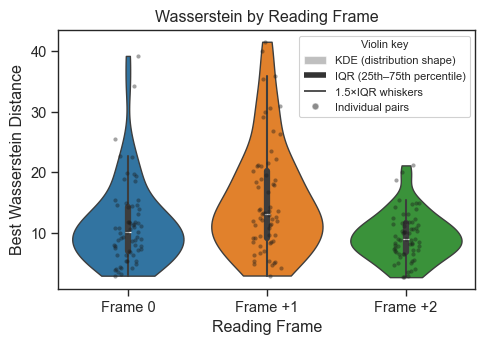

Friedman test on Wasserstein across frames: chi2=87.72, p=0.0000
  Frame 0 vs 1: Wilcoxon W=61.0, p=0.0000
  Frame 0 vs 2: Wilcoxon W=433.0, p=0.0000
  Frame 1 vs 2: Wilcoxon W=11.0, p=0.0000


In [25]:
# === Cell 2: Frame comparison -- violin plots + statistical test ===

frame_order = ['Frame 0', 'Frame +1', 'Frame +2']
frame_palette = {'Frame 0': '#1f77b4', 'Frame +1': '#ff7f0e', 'Frame +2': '#2ca02c'}

fig, ax = plt.subplots(figsize=(5, 3.6))

sns.violinplot(data=df, x='frame_label', y='best_wass', hue='frame_label',
               order=frame_order, hue_order=frame_order,
               palette=frame_palette, inner='box', cut=0, ax=ax, legend=False)
sns.stripplot(data=df, x='frame_label', y='best_wass', order=frame_order,
              color='k', size=3, alpha=0.4, jitter=True, ax=ax)

ax.set_xlabel('Reading Frame')
ax.set_ylabel('Best Wasserstein Distance')
ax.set_title('Wasserstein by Reading Frame')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor='gray', alpha=0.5, label='KDE (distribution shape)'),
    Line2D([0], [0], color='#333333', lw=4, label='IQR (25th–75th percentile)',
           solid_capstyle='butt'),
    Line2D([0], [0], color='#333333', lw=1.2, label='1.5×IQR whiskers',
           solid_capstyle='butt'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='k',
           markersize=5, alpha=0.5, label='Individual pairs'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='upper right',
          framealpha=0.9, title='Violin key', title_fontsize=8)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_frame_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

# Paired Friedman test (each pair contributes one value per frame)
pivot_w = df.pivot_table(index='pair', columns='frame', values='best_wass')
if pivot_w.shape[1] == 3 and len(pivot_w) >= 3:
    stat_f, p_f = stats.friedmanchisquare(pivot_w[0], pivot_w[1], pivot_w[2])
    print(f'Friedman test on Wasserstein across frames: chi2={stat_f:.2f}, p={p_f:.4f}')
    # Pairwise Wilcoxon signed-rank
    for (a, b) in [(0, 1), (0, 2), (1, 2)]:
        s, p = stats.wilcoxon(pivot_w[a], pivot_w[b])
        print(f'  Frame {a} vs {b}: Wilcoxon W={s:.1f}, p={p:.4f}')

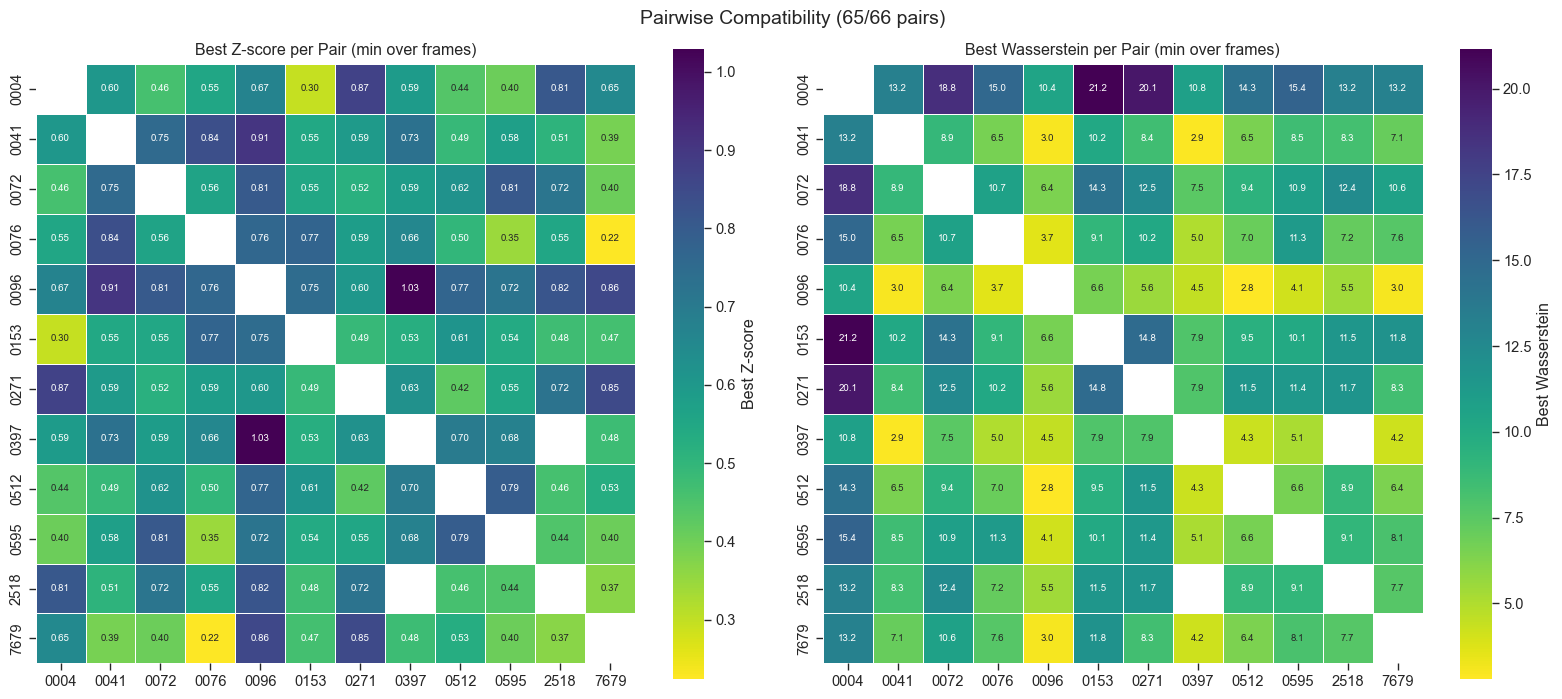

In [4]:
# === Cell 3: Pairwise compatibility matrix -- 12x12 heatmap ===

# Use the best z-score across all 3 overlaps for each pair
df_best_per_pair = df.groupby('pair').agg(
    pf1=('pf1', 'first'), pf2=('pf2', 'first'),
    best_z=('best_z', 'min'), best_wass=('best_wass', 'min'),
).reset_index()

# All families that appear in any pair
all_pf = sorted(set(df_best_per_pair['pf1']) | set(df_best_per_pair['pf2']))
n_pf = len(all_pf)
pf_idx = {pf: i for i, pf in enumerate(all_pf)}

# Build symmetric matrix (NaN for missing pairs)
z_matrix = np.full((n_pf, n_pf), np.nan)
w_matrix = np.full((n_pf, n_pf), np.nan)
for _, row in df_best_per_pair.iterrows():
    i, j = pf_idx[row['pf1']], pf_idx[row['pf2']]
    z_matrix[i, j] = z_matrix[j, i] = row['best_z']
    w_matrix[i, j] = w_matrix[j, i] = row['best_wass']

# Shorten labels
short = [pf.replace('PF0', '').replace('PF', '') for pf in all_pf]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
mask = np.isnan(z_matrix)
sns.heatmap(z_matrix, ax=ax, xticklabels=short, yticklabels=short,
            cmap='viridis_r', annot=True, fmt='.2f', annot_kws={'size': 7},
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'label': 'Best Z-score'})
ax.set_title('Best Z-score per Pair (min over frames)')
ax.set_xlabel('')
ax.set_ylabel('')

ax = axes[1]
mask = np.isnan(w_matrix)
sns.heatmap(w_matrix, ax=ax, xticklabels=short, yticklabels=short,
            cmap='viridis_r', annot=True, fmt='.1f', annot_kws={'size': 7},
            mask=mask, square=True, linewidths=0.5,
            cbar_kws={'label': 'Best Wasserstein'})
ax.set_title('Best Wasserstein per Pair (min over frames)')
ax.set_xlabel('')
ax.set_ylabel('')

fig.suptitle(f'Pairwise Compatibility ({len(df_best_per_pair)}/66 pairs)', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_compatibility_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

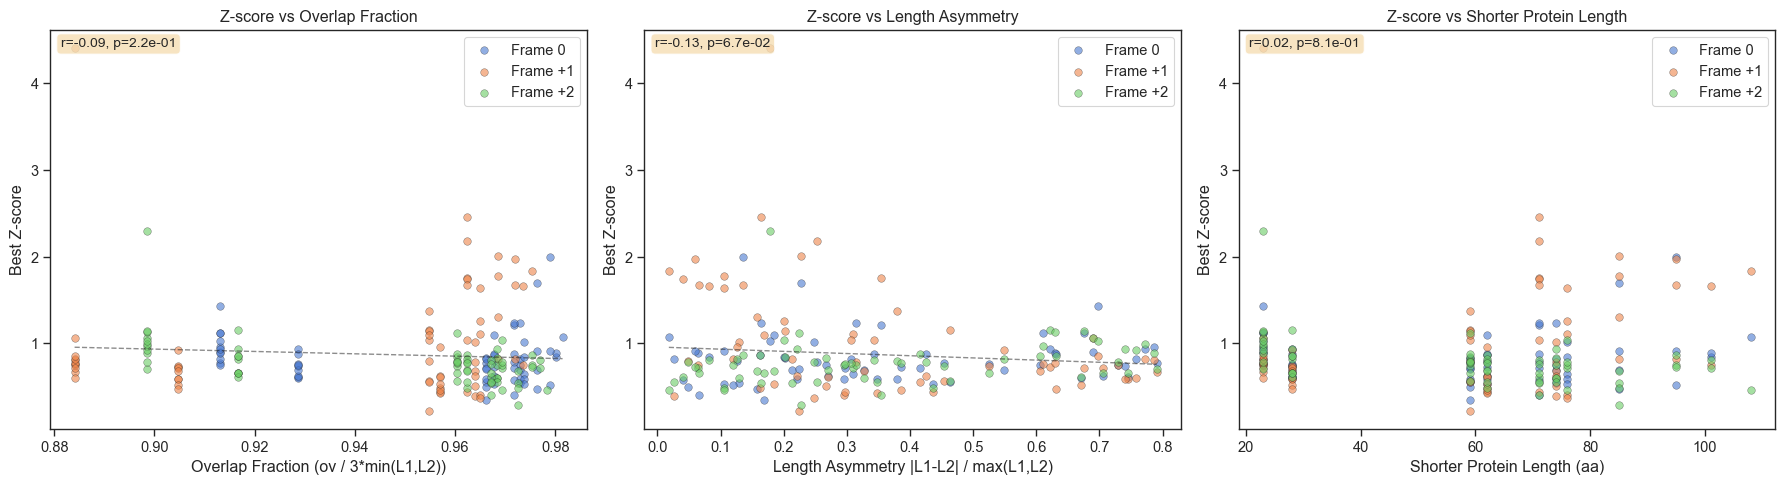

In [23]:
# === Cell 4: Protein size effects ===

df_size = df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Best z-score vs overlap fraction
ax = axes[0]
for frame, grp in df_size.groupby('frame'):
    ax.scatter(grp['overlap_frac'], grp['best_z'], label=FRAME_LABELS[frame],
               alpha=0.6, s=30, edgecolors='k', linewidths=0.3)
ax.set_xlabel('Overlap Fraction (ov / 3*min(L1,L2))')
ax.set_ylabel('Best Z-score')
ax.set_title('Z-score vs Overlap Fraction')
ax.legend()
mask = ~df_size['overlap_frac'].isna()
if mask.sum() > 5:
    r, p = stats.pearsonr(df_size.loc[mask, 'overlap_frac'], df_size.loc[mask, 'best_z'])
    z = np.polyfit(df_size.loc[mask, 'overlap_frac'], df_size.loc[mask, 'best_z'], 1)
    x_fit = np.linspace(df_size['overlap_frac'].min(), df_size['overlap_frac'].max(), 100)
    ax.plot(x_fit, np.polyval(z, x_fit), 'k--', lw=1, alpha=0.5)
    ax.text(0.02, 0.98, f'r={r:.2f}, p={p:.1e}', transform=ax.transAxes,
            va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# (b) Best z-score vs length asymmetry
ax = axes[1]
for frame, grp in df_size.groupby('frame'):
    ax.scatter(grp['length_asym'], grp['best_z'], label=FRAME_LABELS[frame],
               alpha=0.6, s=30, edgecolors='k', linewidths=0.3)
ax.set_xlabel('Length Asymmetry |L1-L2| / max(L1,L2)')
ax.set_ylabel('Best Z-score')
ax.set_title('Z-score vs Length Asymmetry')
ax.legend()
mask = ~df_size['length_asym'].isna()
if mask.sum() > 5:
    r, p = stats.pearsonr(df_size.loc[mask, 'length_asym'], df_size.loc[mask, 'best_z'])
    z = np.polyfit(df_size.loc[mask, 'length_asym'], df_size.loc[mask, 'best_z'], 1)
    x_fit = np.linspace(df_size['length_asym'].min(), df_size['length_asym'].max(), 100)
    ax.plot(x_fit, np.polyval(z, x_fit), 'k--', lw=1, alpha=0.5)
    ax.text(0.02, 0.98, f'r={r:.2f}, p={p:.1e}', transform=ax.transAxes,
            va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# (c) Best z-score vs shorter protein length
ax = axes[2]
df_size['min_L'] = df_size[['L1', 'L2']].min(axis=1)
for frame, grp in df_size.groupby('frame'):
    ax.scatter(grp['min_L'], grp['best_z'], label=FRAME_LABELS[frame],
               alpha=0.6, s=30, edgecolors='k', linewidths=0.3)
ax.set_xlabel('Shorter Protein Length (aa)')
ax.set_ylabel('Best Z-score')
ax.set_title('Z-score vs Shorter Protein Length')
ax.legend()
mask = ~df_size['min_L'].isna()
if mask.sum() > 5:
    r, p = stats.pearsonr(df_size.loc[mask, 'min_L'], df_size.loc[mask, 'best_z'])
    ax.text(0.02, 0.98, f'r={r:.2f}, p={p:.1e}', transform=ax.transAxes,
            va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_size_effects.png'), dpi=150, bbox_inches='tight')
plt.show()

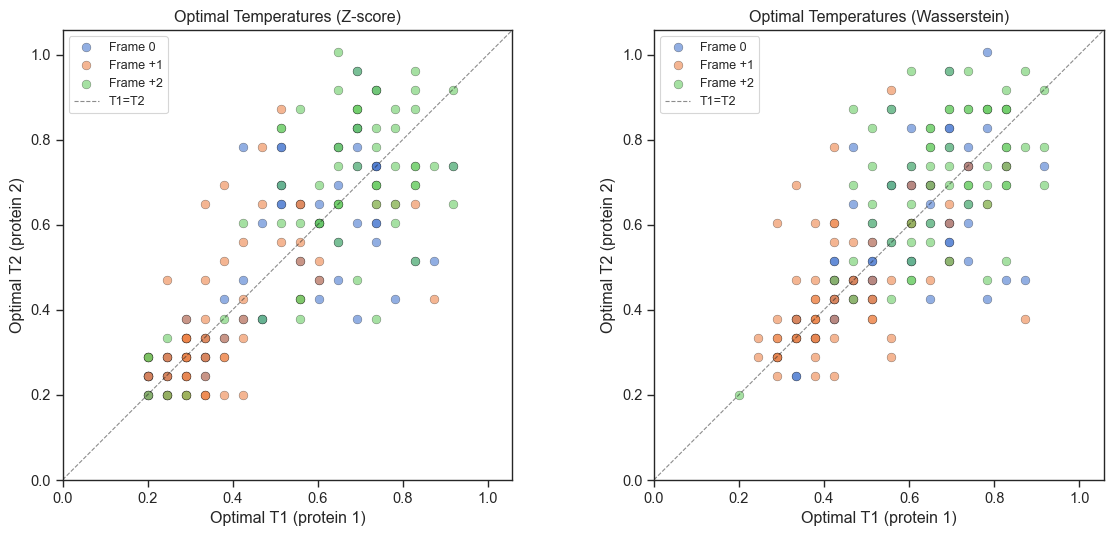

Optimal T (z-score):
  T1: median=0.514, IQR=[0.290, 0.693]
  T2: median=0.514, IQR=[0.290, 0.693]
  T1/T2 ratio: median=1.00


In [6]:
# === Cell 5: Optimal temperature landscape ===

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

# (a) Best z-score temperatures
ax = axes[0]
for frame, grp in df.groupby('frame'):
    ax.scatter(grp['best_z_T1'], grp['best_z_T2'], label=FRAME_LABELS[frame],
               alpha=0.6, s=40, edgecolors='k', linewidths=0.3)
lim = max(df['best_z_T1'].max(), df['best_z_T2'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5, label='T1=T2')
ax.set_xlabel('Optimal T1 (protein 1)')
ax.set_ylabel('Optimal T2 (protein 2)')
ax.set_title('Optimal Temperatures (Z-score)')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect('equal')
ax.legend(fontsize=9)

# (b) Best Wasserstein temperatures
ax = axes[1]
for frame, grp in df.groupby('frame'):
    ax.scatter(grp['best_wass_T1'], grp['best_wass_T2'], label=FRAME_LABELS[frame],
               alpha=0.6, s=40, edgecolors='k', linewidths=0.3)
lim = max(df['best_wass_T1'].max(), df['best_wass_T2'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5, label='T1=T2')
ax.set_xlabel('Optimal T1 (protein 1)')
ax.set_ylabel('Optimal T2 (protein 2)')
ax.set_title('Optimal Temperatures (Wasserstein)')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect('equal')
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_temp_landscape.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print('Optimal T (z-score):')
print(f'  T1: median={df["best_z_T1"].median():.3f}, IQR=[{df["best_z_T1"].quantile(0.25):.3f}, {df["best_z_T1"].quantile(0.75):.3f}]')
print(f'  T2: median={df["best_z_T2"].median():.3f}, IQR=[{df["best_z_T2"].quantile(0.25):.3f}, {df["best_z_T2"].quantile(0.75):.3f}]')
t_ratio = df['best_z_T1'] / df['best_z_T2']
print(f'  T1/T2 ratio: median={t_ratio.median():.2f}')

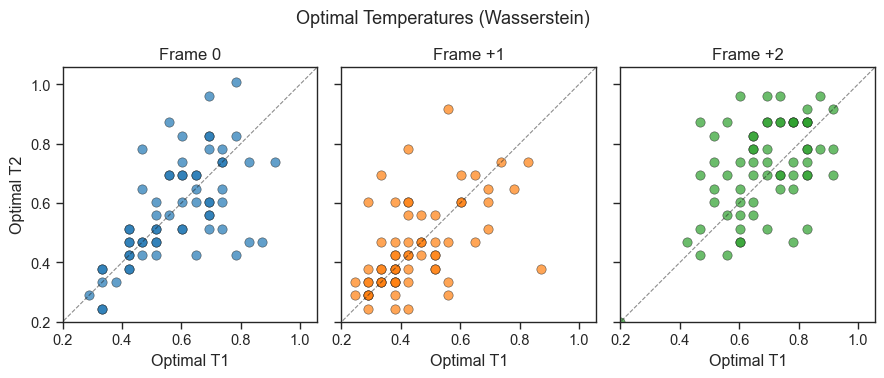

Frame 0: T1/T2 median=1.00, T2>T1 in 26/65 pairs
Frame +1: T1/T2 median=1.00, T2>T1 in 24/65 pairs
Frame +2: T1/T2 median=0.95, T2>T1 in 35/65 pairs


In [15]:
# === Cell 5b: Optimal temperature landscape -- faceted by frame (Wasserstein only) ===

fig, axes = plt.subplots(1, 3, figsize=(9, 3.6), sharey=True)

lim = max(df['best_wass_T1'].max(), df['best_wass_T2'].max()) * 1.05
frame_colors = {'Frame 0': '#1f77b4', 'Frame +1': '#ff7f0e', 'Frame +2': '#2ca02c'}

for ax, (frame, grp) in zip(axes, df.groupby('frame')):
    label = FRAME_LABELS[frame]
    ax.scatter(grp['best_wass_T1'], grp['best_wass_T2'],
               color=frame_colors[label], alpha=0.7, s=45,
               edgecolors='k', linewidths=0.4)
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(0.2, lim)
    ax.set_ylim(0.2, lim)
    ax.set_aspect('equal')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Optimal T1')

axes[0].set_ylabel('Optimal T2')

fig.suptitle('Optimal Temperatures (Wasserstein)', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_temp_landscape_faceted.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary stats per frame
for frame, grp in df.groupby('frame'):
    ratio = grp['best_wass_T1'] / grp['best_wass_T2']
    above = (grp['best_wass_T2'] > grp['best_wass_T1']).sum()
    print(f"{FRAME_LABELS[frame]}: T1/T2 median={ratio.median():.2f}, "
          f"T2>T1 in {above}/{len(grp)} pairs")

Best frame agrees (z vs W): 16/65 pairs (25%)


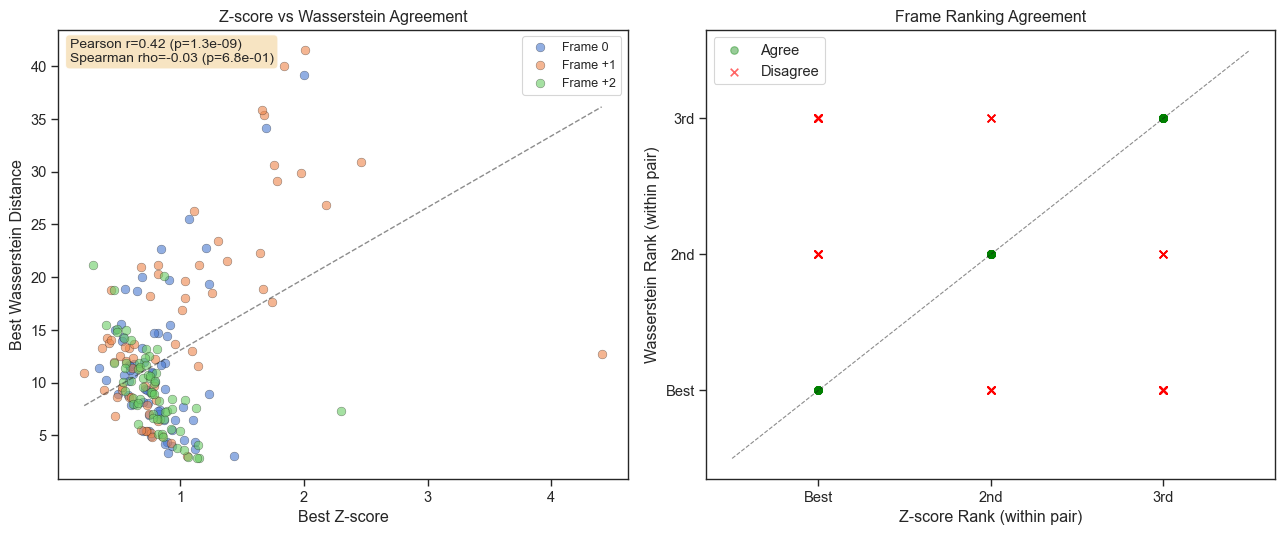

In [6]:
# === Cell 6: Z-score vs Wasserstein agreement ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# (a) Scatter of best z vs best Wasserstein
ax = axes[0]
for frame, grp in df.groupby('frame'):
    ax.scatter(grp['best_z'], grp['best_wass'], label=FRAME_LABELS[frame],
               alpha=0.6, s=40, edgecolors='k', linewidths=0.3)
ax.set_xlabel('Best Z-score')
ax.set_ylabel('Best Wasserstein Distance')
ax.set_title('Z-score vs Wasserstein Agreement')

r, p = stats.pearsonr(df['best_z'], df['best_wass'])
rho, p_s = stats.spearmanr(df['best_z'], df['best_wass'])
ax.text(0.02, 0.98, f'Pearson r={r:.2f} (p={p:.1e})\nSpearman rho={rho:.2f} (p={p_s:.1e})',
        transform=ax.transAxes, va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
# Trend line
z = np.polyfit(df['best_z'], df['best_wass'], 1)
x_fit = np.linspace(df['best_z'].min(), df['best_z'].max(), 100)
ax.plot(x_fit, np.polyval(z, x_fit), 'k--', lw=1, alpha=0.5)
ax.legend(fontsize=9)

# (b) Rank agreement -- flag disagreements
ax = axes[1]
df_temp = df.copy()
df_temp['z_rank'] = df_temp.groupby('pair')['best_z'].rank()
df_temp['w_rank'] = df_temp.groupby('pair')['best_wass'].rank()
agree = (df_temp['z_rank'] == df_temp['w_rank'])

ax.scatter(df_temp.loc[agree, 'z_rank'], df_temp.loc[agree, 'w_rank'],
           alpha=0.4, s=30, c='green', label='Agree')
ax.scatter(df_temp.loc[~agree, 'z_rank'], df_temp.loc[~agree, 'w_rank'],
           alpha=0.6, s=30, c='red', marker='x', label='Disagree')
ax.plot([0.5, 3.5], [0.5, 3.5], 'k--', lw=0.8, alpha=0.5)
ax.set_xlabel('Z-score Rank (within pair)')
ax.set_ylabel('Wasserstein Rank (within pair)')
ax.set_title('Frame Ranking Agreement')
ax.set_xticks([1, 2, 3])
ax.set_yticks([1, 2, 3])
ax.set_xticklabels(['Best', '2nd', '3rd'])
ax.set_yticklabels(['Best', '2nd', '3rd'])
ax.legend()

# Count how often best frame agrees
best_z_frame = df_temp[df_temp['z_rank'] == 1.0].set_index('pair')['frame']
best_w_frame = df_temp[df_temp['w_rank'] == 1.0].set_index('pair')['frame']
common = best_z_frame.index.intersection(best_w_frame.index)
n_agree = (best_z_frame[common] == best_w_frame[common]).sum()
print(f'Best frame agrees (z vs W): {n_agree}/{len(common)} pairs ({100*n_agree/len(common):.0f}%)')

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_z_vs_wass.png'), dpi=150, bbox_inches='tight')
plt.show()

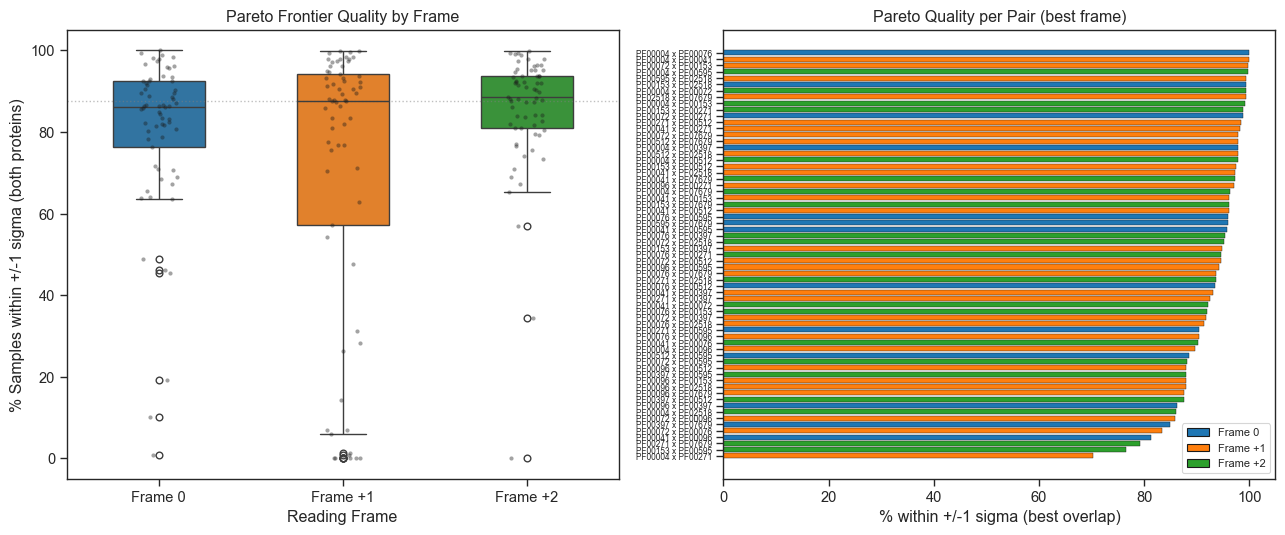

Overall: median 87.5%, mean 78.6%
  Frame 0: median 86.0%, mean 80.0%
  Frame +1: median 87.6%, mean 70.4%
  Frame +2: median 88.5%, mean 85.3%


In [7]:
# === Cell 7: Pareto frontier summary -- % within +/-1 sigma ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# (a) Distribution of % within +/-1 sigma by frame
ax = axes[0]
sns.boxplot(data=df, x='frame_label', y='within_1sig', hue='frame_label',
            order=frame_order, hue_order=frame_order,
            palette=frame_palette, ax=ax, width=0.5, legend=False)
sns.stripplot(data=df, x='frame_label', y='within_1sig', order=frame_order,
              color='k', size=3, alpha=0.4, jitter=True, ax=ax)
ax.set_xlabel('Reading Frame')
ax.set_ylabel('% Samples within +/-1 sigma (both proteins)')
ax.set_title('Pareto Frontier Quality by Frame')
ax.axhline(y=df['within_1sig'].median(), color='gray', ls=':', lw=1, alpha=0.5)

# (b) Sorted bar chart of % within +/-1 sigma for best overlap per pair
df_pareto = df.loc[df.groupby('pair')['within_1sig'].idxmax()]
df_pareto = df_pareto.sort_values('within_1sig', ascending=True)

ax = axes[1]
colors = [{'Frame 0': '#1f77b4', 'Frame +1': '#ff7f0e', 'Frame +2': '#2ca02c'}[fl]
          for fl in df_pareto['frame_label']]
bars = ax.barh(range(len(df_pareto)), df_pareto['within_1sig'], color=colors,
               edgecolor='k', linewidth=0.3)
ax.set_yticks(range(len(df_pareto)))
labels = [f"{r['pair'].replace('_', ' x ')}" for _, r in df_pareto.iterrows()]
ax.set_yticklabels(labels, fontsize=6)
ax.set_xlabel('% within +/-1 sigma (best overlap)')
ax.set_title('Pareto Quality per Pair (best frame)')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='k', label=FRAME_LABELS[i])
                   for i, c in enumerate(['#1f77b4', '#ff7f0e', '#2ca02c'])]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_pareto_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print(f'Overall: median {df["within_1sig"].median():.1f}%, '
      f'mean {df["within_1sig"].mean():.1f}%')
for f_label in frame_order:
    sub = df[df['frame_label'] == f_label]['within_1sig']
    print(f'  {f_label}: median {sub.median():.1f}%, mean {sub.mean():.1f}%')

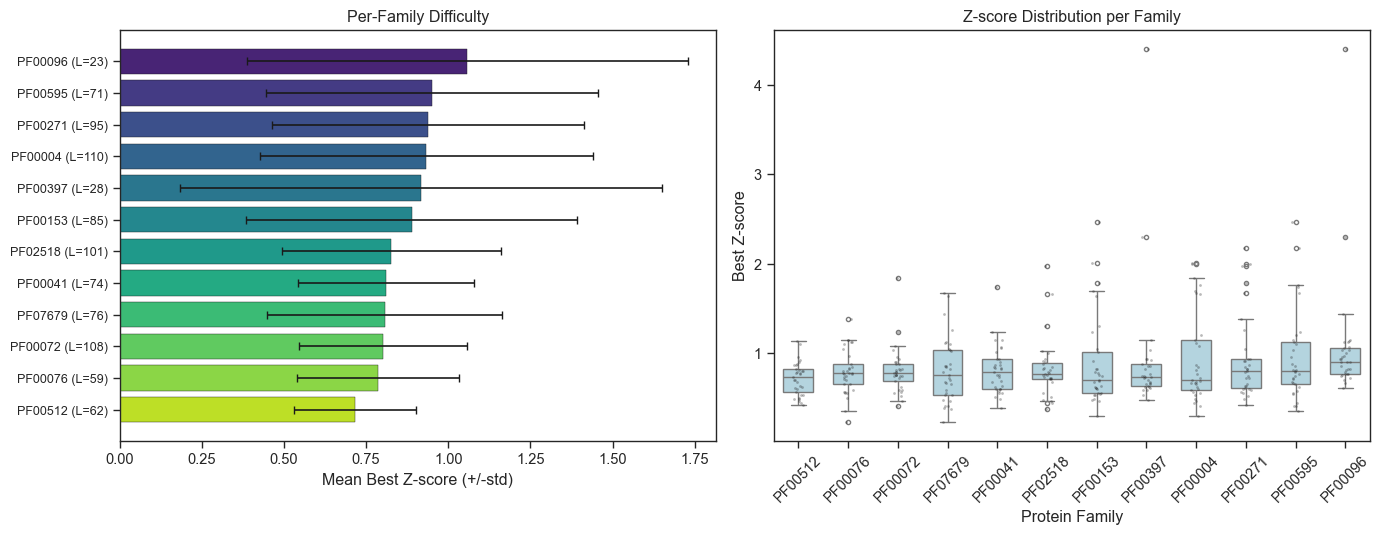

Family length vs mean z-score: r=-0.29, p=0.353

Easiest families (lowest z): ['PF00512', 'PF00076', 'PF00072']
Hardest families (highest z): ['PF00271', 'PF00595', 'PF00096']


In [8]:
# === Cell 8: Per-family difficulty -- average best z-score per protein family ===

# Each family appears in multiple pairs; compute its average best z-score
family_rows = []
for _, row in df.iterrows():
    family_rows.append({'family': row['pf1'], 'best_z': row['best_z'],
                        'best_wass': row['best_wass'], 'frame': row['frame']})
    family_rows.append({'family': row['pf2'], 'best_z': row['best_z'],
                        'best_wass': row['best_wass'], 'frame': row['frame']})

df_fam = pd.DataFrame(family_rows)

# Aggregate per family
df_fam_agg = df_fam.groupby('family').agg(
    mean_z=('best_z', 'mean'),
    median_z=('best_z', 'median'),
    std_z=('best_z', 'std'),
    mean_wass=('best_wass', 'mean'),
    n_appearances=('best_z', 'count'),
).reset_index()
df_fam_agg['length'] = df_fam_agg['family'].map(PF_LENGTHS)
df_fam_agg = df_fam_agg.sort_values('mean_z')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Bar chart of mean z-score per family
ax = axes[0]
colors = plt.cm.viridis_r(np.linspace(0.1, 0.9, len(df_fam_agg)))
ax.barh(range(len(df_fam_agg)), df_fam_agg['mean_z'], xerr=df_fam_agg['std_z'],
        color=colors, edgecolor='k', linewidth=0.3, capsize=3)
ax.set_yticks(range(len(df_fam_agg)))
ax.set_yticklabels([f"{r['family']} (L={int(r['length'])})"
                    for _, r in df_fam_agg.iterrows()], fontsize=9)
ax.set_xlabel('Mean Best Z-score (+/-std)')
ax.set_title('Per-Family Difficulty')

# (b) Box plot: z-score distribution per family
ax = axes[1]
fam_order = df_fam_agg['family'].tolist()
sns.boxplot(data=df_fam, x='family', y='best_z', order=fam_order,
            color='lightblue', ax=ax, width=0.6, fliersize=3)
sns.stripplot(data=df_fam, x='family', y='best_z', order=fam_order,
              color='k', size=2, alpha=0.3, jitter=True, ax=ax)
ax.set_xlabel('Protein Family')
ax.set_ylabel('Best Z-score')
ax.set_title('Z-score Distribution per Family')
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_family_difficulty.png'), dpi=150, bbox_inches='tight')
plt.show()

# Correlation: family length vs difficulty
r, p = stats.pearsonr(df_fam_agg['length'], df_fam_agg['mean_z'])
print(f'Family length vs mean z-score: r={r:.2f}, p={p:.3f}')
print(f'\nEasiest families (lowest z): {df_fam_agg.head(3)["family"].tolist()}')
print(f'Hardest families (highest z): {df_fam_agg.tail(3)["family"].tolist()}')

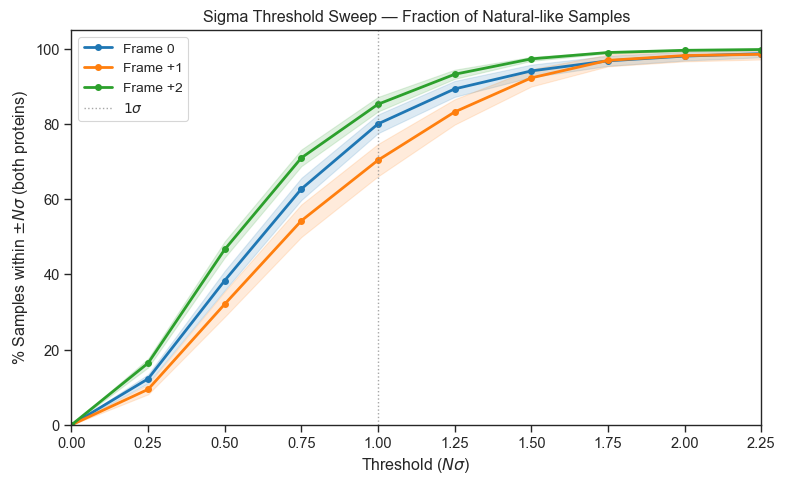


± 0.5σ:
  Frame 0: 38.4%
  Frame +1: 32.1%
  Frame +2: 46.7%

± 1.0σ:
  Frame 0: 80.0%
  Frame +1: 70.4%
  Frame +2: 85.3%

± 1.5σ:
  Frame 0: 94.1%
  Frame +1: 92.3%
  Frame +2: 97.3%

± 2.0σ:
  Frame 0: 98.1%
  Frame +1: 98.2%
  Frame +2: 99.6%


In [13]:
# === Cell 9: Sigma threshold sweep — fraction within ±Nσ by frame ===

sigma_thresholds = np.arange(0, 2.5, 0.25)

# Recompute from raw energy samples at each threshold
sweep_rows = []
for key, d in raw_data.items():
    pf1, pf2 = str(d['pf1']), str(d['pf2'])
    nat_mean1, nat_std1 = float(d['nat_mean_1']), float(d['nat_std_1'])
    nat_mean2, nat_std2 = float(d['nat_mean_2']), float(d['nat_std_2'])

    for ov in d['overlap_lengths']:
        ov = int(ov)
        E1 = d[f'wass_best_E1_{ov}'][0]
        E2 = d[f'wass_best_E2_{ov}'][0]
        z1 = (E1 - nat_mean1) / nat_std1
        z2 = (E2 - nat_mean2) / nat_std2

        for sig in sigma_thresholds:
            frac = float(np.mean((np.abs(z1) <= sig) & (np.abs(z2) <= sig))) * 100
            sweep_rows.append({
                'pair': key, 'frame': ov % 3,
                'frame_label': FRAME_LABELS[ov % 3],
                'sigma': sig, 'within_pct': frac,
            })

df_sweep = pd.DataFrame(sweep_rows)

# Aggregate: mean ± sem across pairs for each (frame, sigma)
df_sweep_agg = df_sweep.groupby(['frame', 'frame_label', 'sigma']).agg(
    mean_pct=('within_pct', 'mean'),
    sem_pct=('within_pct', 'sem'),
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
for frame in [0, 1, 2]:
    sub = df_sweep_agg[df_sweep_agg['frame'] == frame]
    label = FRAME_LABELS[frame]
    color = frame_palette[label]
    ax.plot(sub['sigma'], sub['mean_pct'], '-o', color=color, label=label,
            ms=4, lw=2)
    ax.fill_between(sub['sigma'],
                    sub['mean_pct'] - sub['sem_pct'],
                    sub['mean_pct'] + sub['sem_pct'],
                    color=color, alpha=0.15)

ax.axvline(1.0, color='gray', ls=':', lw=1, alpha=0.7, label=r'$1\sigma$')
ax.set_xlabel(r'Threshold ($N\sigma$)')
ax.set_ylabel('% Samples within $\\pm N\\sigma$ (both proteins)')
ax.set_title('Sigma Threshold Sweep — Fraction of Natural-like Samples')
ax.legend(fontsize=10)
ax.set_xlim(sigma_thresholds[0], sigma_thresholds[-1])
ax.set_ylim(0, 105)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_sigma_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print key thresholds
for sig in [0.5, 1.0, 1.5, 2.0]:
    print(f'\n± {sig}σ:')
    for frame in [0, 1, 2]:
        val = df_sweep_agg[(df_sweep_agg['frame'] == frame) &
                           (np.isclose(df_sweep_agg['sigma'], sig))]['mean_pct'].values[0]
        print(f'  {FRAME_LABELS[frame]}: {val:.1f}%')

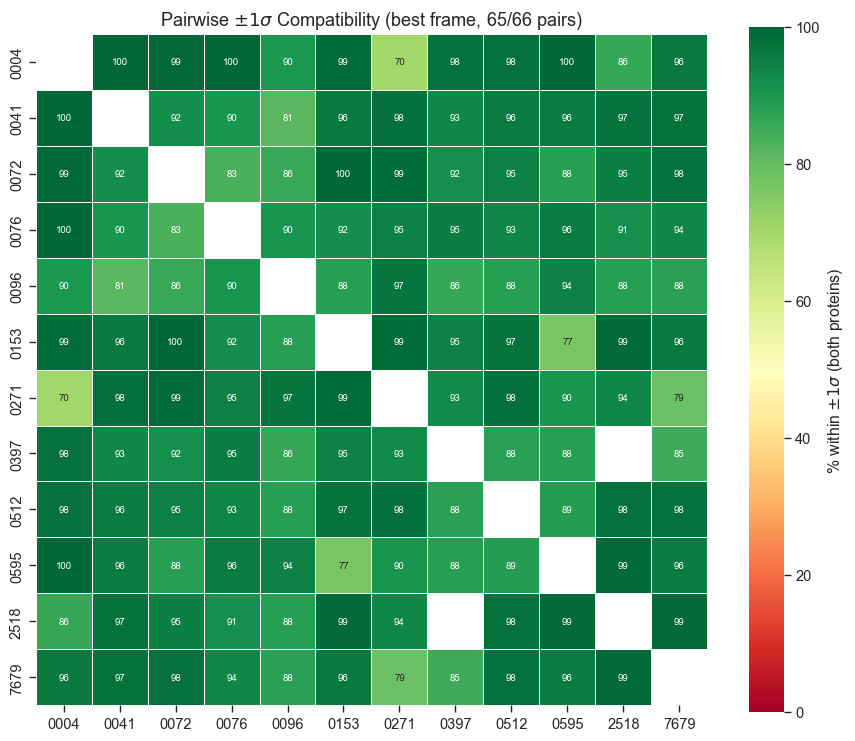

Pairs with ≥90% within ±1σ: 47/65
Pairs with <50% within ±1σ: 0/65


In [10]:
# === Cell 10: Within ±1σ compatibility matrix ===

# Best within_1sig across all 3 overlaps for each pair
df_best_1sig = df.groupby('pair').agg(
    pf1=('pf1', 'first'), pf2=('pf2', 'first'),
    best_within=('within_1sig', 'max'),
).reset_index()

# Build symmetric matrix
sig_matrix = np.full((n_pf, n_pf), np.nan)
for _, row in df_best_1sig.iterrows():
    i, j = pf_idx[row['pf1']], pf_idx[row['pf2']]
    sig_matrix[i, j] = sig_matrix[j, i] = row['best_within']

fig, ax = plt.subplots(figsize=(9, 7.5))
mask = np.isnan(sig_matrix)
sns.heatmap(sig_matrix, ax=ax, xticklabels=short, yticklabels=short,
            cmap='RdYlGn', annot=True, fmt='.0f', annot_kws={'size': 7},
            mask=mask, square=True, linewidths=0.5, vmin=0, vmax=100,
            cbar_kws={'label': '% within $\\pm 1\\sigma$ (both proteins)'})
ax.set_title(f'Pairwise $\\pm 1\\sigma$ Compatibility (best frame, {len(df_best_1sig)}/66 pairs)',
             fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_within1sig_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary
high = df_best_1sig[df_best_1sig['best_within'] >= 90]
low = df_best_1sig[df_best_1sig['best_within'] < 50]
print(f'Pairs with ≥90% within ±1σ: {len(high)}/{len(df_best_1sig)}')
print(f'Pairs with <50% within ±1σ: {len(low)}/{len(df_best_1sig)}')
if len(low) > 0:
    print('Low pairs:', low[['pair', 'best_within']].to_string(index=False))

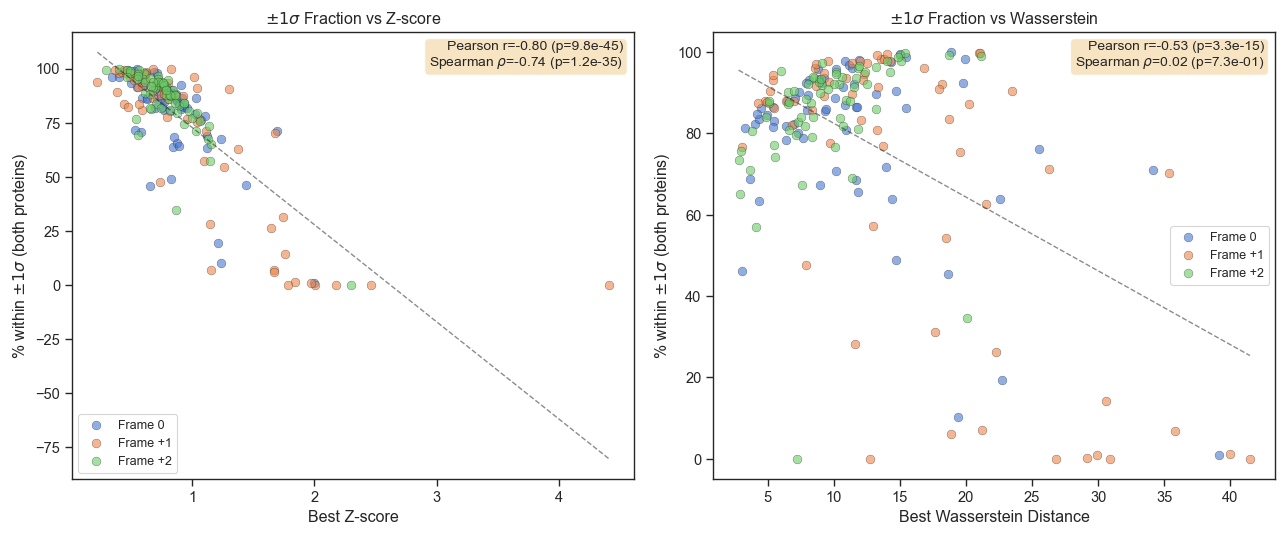

within_1sig vs z-score:    r=-0.80, rho=-0.74
within_1sig vs Wasserstein: r=-0.53, rho=0.02
→ ±1σ fraction tracks z-score more closely than Wasserstein


In [11]:
# === Cell 11: Within ±1σ vs Z-score / Wasserstein ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# (a) within_1sig vs best z-score
ax = axes[0]
for frame, grp in df.groupby('frame'):
    ax.scatter(grp['best_z'], grp['within_1sig'], label=FRAME_LABELS[frame],
               alpha=0.6, s=40, edgecolors='k', linewidths=0.3)
ax.set_xlabel('Best Z-score')
ax.set_ylabel('% within $\\pm 1\\sigma$ (both proteins)')
ax.set_title('$\\pm 1\\sigma$ Fraction vs Z-score')

r_z, p_z = stats.pearsonr(df['best_z'], df['within_1sig'])
rho_z, ps_z = stats.spearmanr(df['best_z'], df['within_1sig'])
ax.text(0.98, 0.98, f'Pearson r={r_z:.2f} (p={p_z:.1e})\nSpearman $\\rho$={rho_z:.2f} (p={ps_z:.1e})',
        transform=ax.transAxes, va='top', ha='right', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
# Trend line
coeffs = np.polyfit(df['best_z'], df['within_1sig'], 1)
x_fit = np.linspace(df['best_z'].min(), df['best_z'].max(), 100)
ax.plot(x_fit, np.polyval(coeffs, x_fit), 'k--', lw=1, alpha=0.5)
ax.legend(fontsize=9)

# (b) within_1sig vs best Wasserstein
ax = axes[1]
for frame, grp in df.groupby('frame'):
    ax.scatter(grp['best_wass'], grp['within_1sig'], label=FRAME_LABELS[frame],
               alpha=0.6, s=40, edgecolors='k', linewidths=0.3)
ax.set_xlabel('Best Wasserstein Distance')
ax.set_ylabel('% within $\\pm 1\\sigma$ (both proteins)')
ax.set_title('$\\pm 1\\sigma$ Fraction vs Wasserstein')

r_w, p_w = stats.pearsonr(df['best_wass'], df['within_1sig'])
rho_w, ps_w = stats.spearmanr(df['best_wass'], df['within_1sig'])
ax.text(0.98, 0.98, f'Pearson r={r_w:.2f} (p={p_w:.1e})\nSpearman $\\rho$={rho_w:.2f} (p={ps_w:.1e})',
        transform=ax.transAxes, va='top', ha='right', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
coeffs = np.polyfit(df['best_wass'], df['within_1sig'], 1)
x_fit = np.linspace(df['best_wass'].min(), df['best_wass'].max(), 100)
ax.plot(x_fit, np.polyval(coeffs, x_fit), 'k--', lw=1, alpha=0.5)
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(os.path.join(SAVE_DIR, 'cross_within1sig_vs_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'within_1sig vs z-score:    r={r_z:.2f}, rho={rho_z:.2f}')
print(f'within_1sig vs Wasserstein: r={r_w:.2f}, rho={rho_w:.2f}')
if abs(rho_z) > 0.8 and abs(rho_w) > 0.8:
    print('→ Strong correlation with both metrics — ±1σ fraction is largely redundant')
elif abs(rho_z) > abs(rho_w) + 0.15:
    print('→ ±1σ fraction tracks z-score more closely than Wasserstein')
elif abs(rho_w) > abs(rho_z) + 0.15:
    print('→ ±1σ fraction tracks Wasserstein more closely than z-score')
else:
    print('→ ±1σ fraction has moderate/comparable correlation with both metrics')